In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
# Check columns list and missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Check duplicate rows
df.duplicated().sum()

0

In [7]:
# Check variable data types
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
#Overall Churn Rate
mean_churn=np.mean(df['Exited'])*100
print(f"Average Churn Rate: {mean_churn:.2f}%")

Average Churn Rate: 20.37%


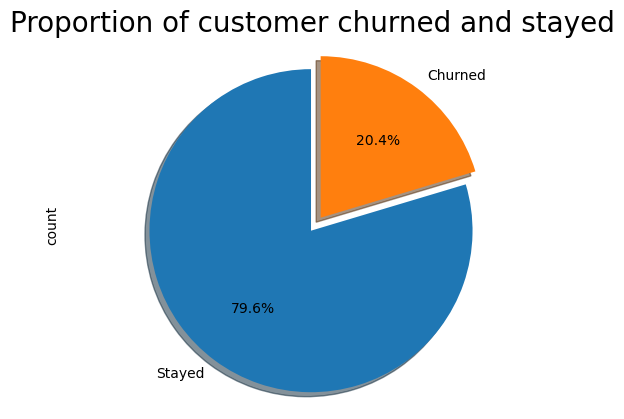

In [9]:
label=['Stayed', 'Churned']
df['Exited'].value_counts().plot(kind='pie', autopct='%1.1f%%',labels=label,
                                 shadow=True,explode=[0,0.1],startangle=90)
plt.axis("equal")
plt.title("Proportion of customer churned and stayed", size = 20)
plt.show()

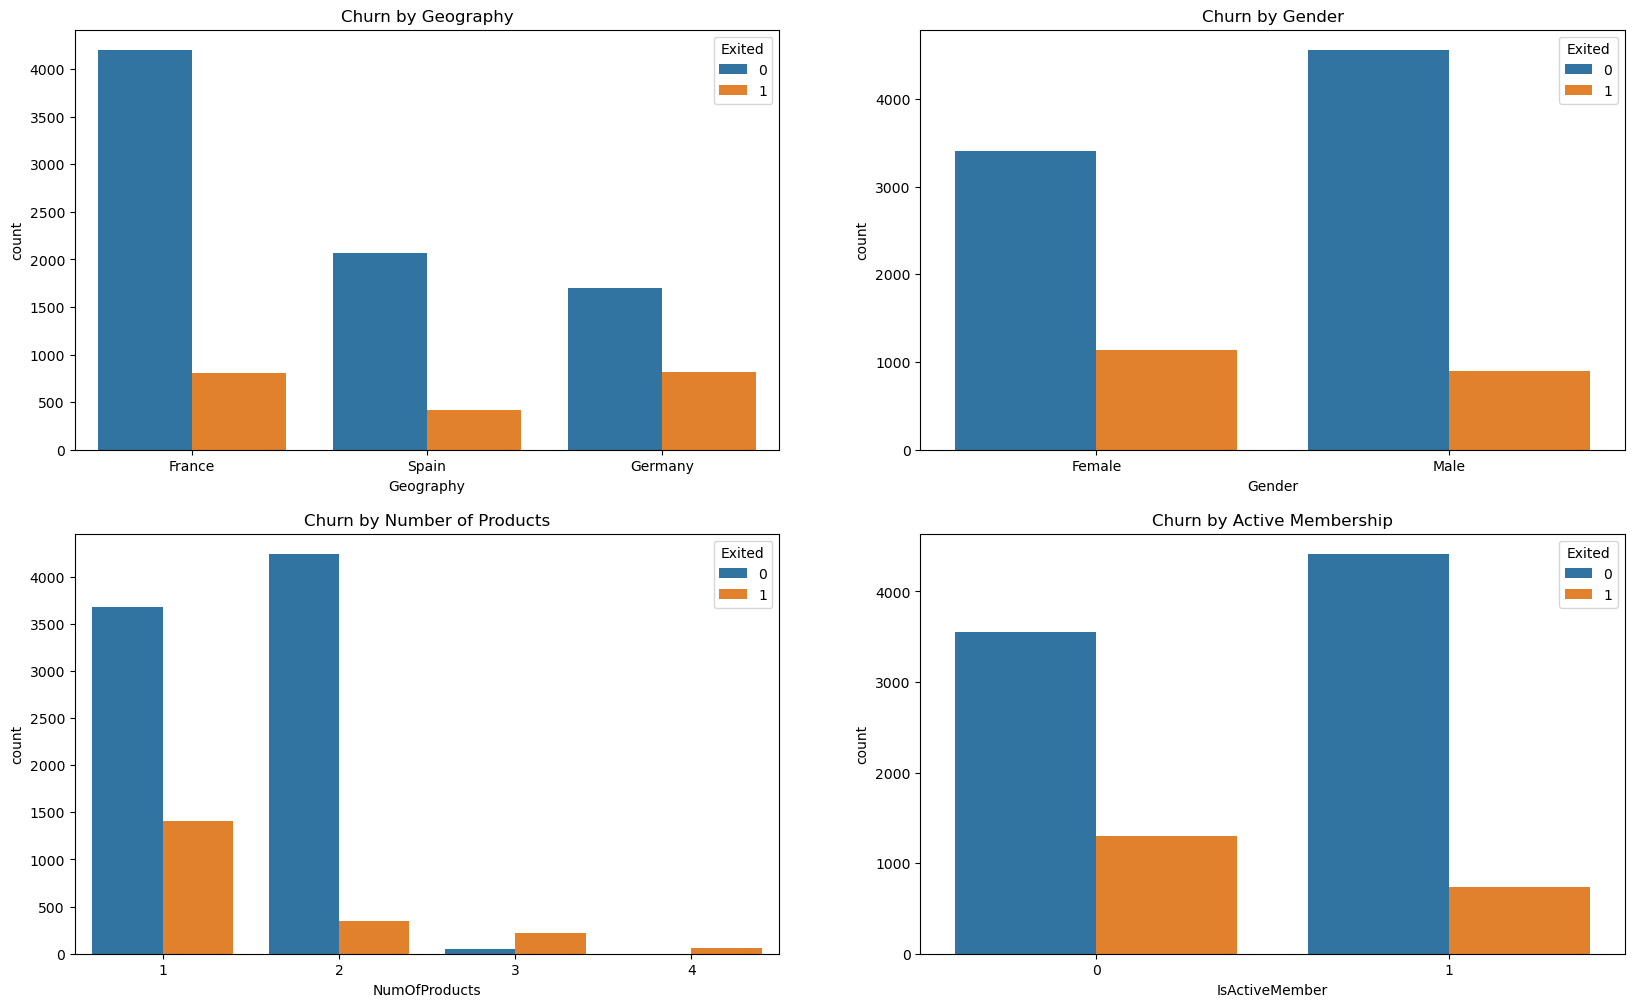

In [10]:
fig, axis = plt.subplots(2, 2, figsize=(20, 12))
sns.countplot(x='Geography', hue = 'Exited',data = df, ax=axis[0][0])
axis[0,0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue = 'Exited',data = df, ax=axis[0][1])
axis[0,1].set_title('Churn by Gender')

sns.countplot(x='NumOfProducts', hue = 'Exited',data = df, ax=axis[1][0])
axis[1,0].set_title('Churn by Number of Products')

sns.countplot(x='IsActiveMember', hue = 'Exited',data = df, ax=axis[1][1])
axis[1,1].set_title('Churn by Active Membership')

plt.show()

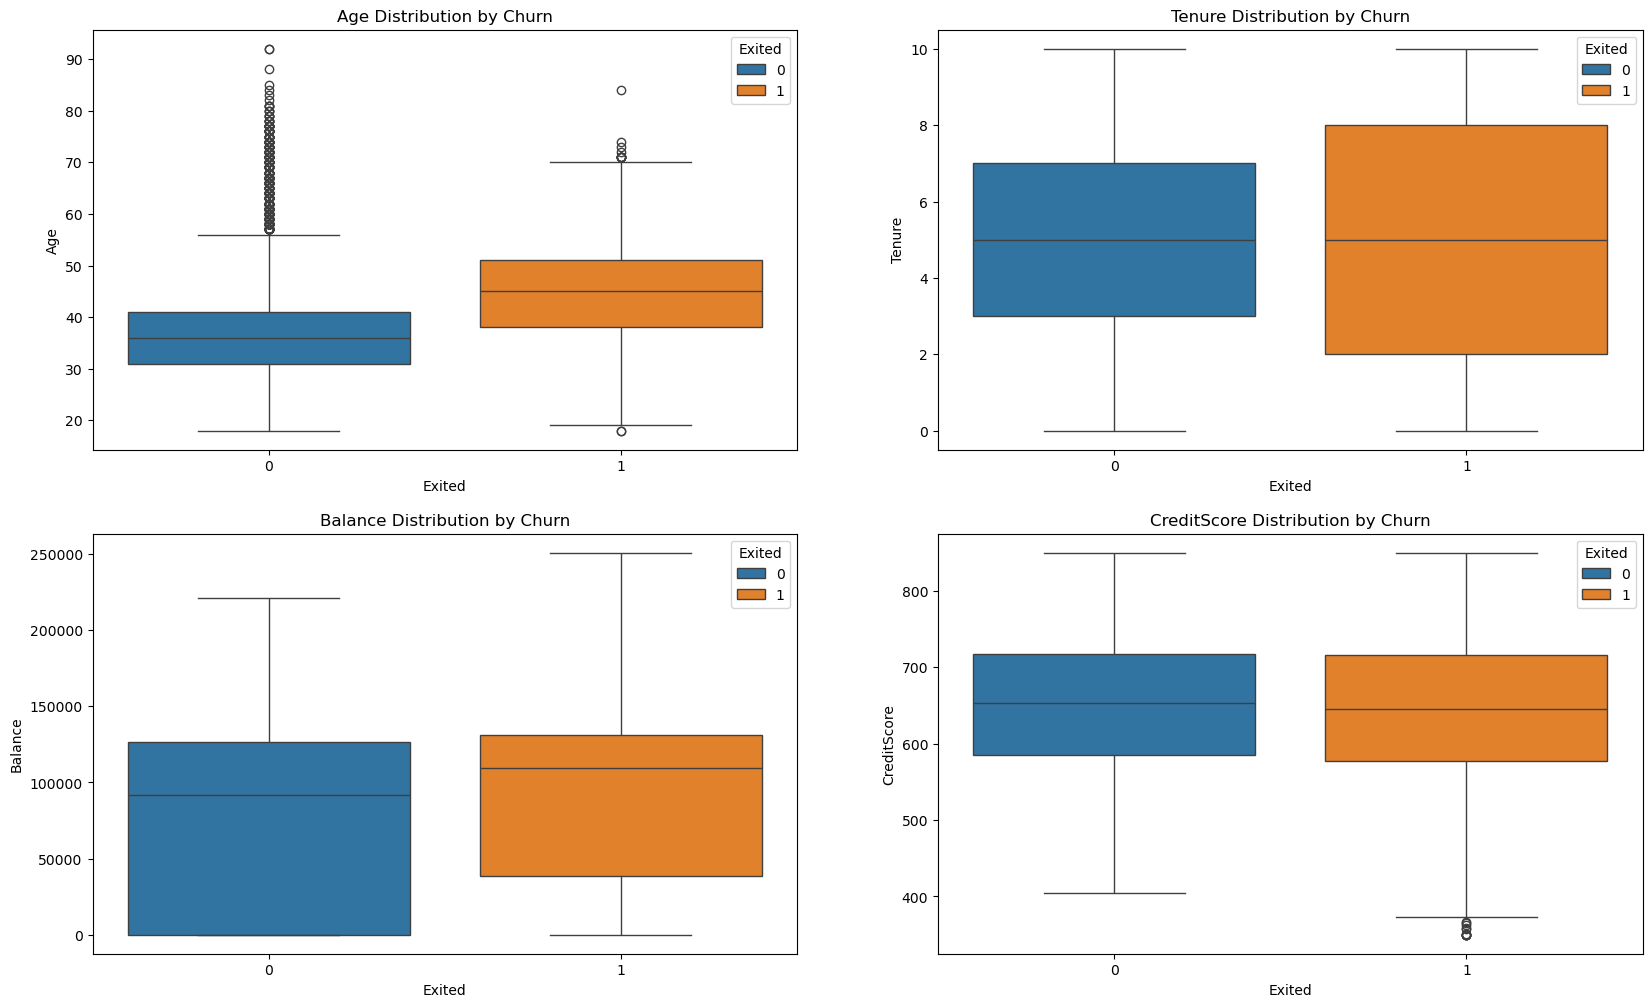

In [11]:
fig, axarr = plt.subplots(2, 2, figsize=(20, 12))

sns.boxplot(y='Age',x = 'Exited', hue = 'Exited',data = df , ax=axarr[0][0])
axarr[0,0].set_title('Age Distribution by Churn')

sns.boxplot(y='Tenure',x = 'Exited', hue = 'Exited',data = df, ax=axarr[0][1])
axarr[0,1].set_title('Tenure Distribution by Churn')

sns.boxplot(y='Balance',x = 'Exited', hue = 'Exited',data = df, ax=axarr[1][0])
axarr[1,0].set_title('Balance Distribution by Churn')

sns.boxplot(y='CreditScore',x = 'Exited', hue = 'Exited',data = df, ax=axarr[1][1])
axarr[1,1].set_title('CreditScore Distribution by Churn')


plt.show()

In [12]:
print("Churn by Geography:", df.groupby('Geography')['Exited'].mean().round(4))

Churn by Geography: Geography
France     0.1615
Germany    0.3244
Spain      0.1667
Name: Exited, dtype: float64


In [13]:
print("Churn by Gender:", df.groupby('Gender')['Exited'].mean().round(3))

Churn by Gender: Gender
Female    0.251
Male      0.165
Name: Exited, dtype: float64


In [14]:
print("Mean age - stayed vs churned:", df.groupby('Exited')['Age'].mean().round(1))

Mean age - stayed vs churned: Exited
0    37.4
1    44.8
Name: Age, dtype: float64


In [15]:
print("Churn by NumOfProducts:", df.groupby('NumOfProducts')['Exited'].mean().round(3))

Churn by NumOfProducts: NumOfProducts
1    0.277
2    0.076
3    0.827
4    1.000
Name: Exited, dtype: float64


In [16]:
print("Mean balance - stayed vs churned:", df.groupby('Exited')['Balance'].mean().round(2))

Mean balance - stayed vs churned: Exited
0    72745.30
1    91108.54
Name: Balance, dtype: float64


In [17]:
print("Balance-churn correlation:", df['Balance'].corr(df['Exited']).round(3))

Balance-churn correlation: 0.119


In [18]:
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [19]:
df_model['AgeGroup'] = pd.cut(df_model['Age'], bins=[17,30,40,50,60,100],
                                labels=['18-30','31-40','41-50','51-60','60+'])
df_model['ZeroBalance'] = (df_model['Balance'] == 0).astype(int)

print("Churn rate by AgeGroup:")
print(df_model.groupby('AgeGroup', observed=True)['Exited'].mean().round(3))

Churn rate by AgeGroup:
AgeGroup
18-30    0.075
31-40    0.121
41-50    0.340
51-60    0.562
60+      0.248
Name: Exited, dtype: float64


In [20]:
print("\nChurn rate by ZeroBalance flag:")
print(df_model.groupby('ZeroBalance')['Exited'].mean().round(3))


Churn rate by ZeroBalance flag:
ZeroBalance
0    0.241
1    0.138
Name: Exited, dtype: float64


In [21]:
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,ZeroBalance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,1
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,0


In [22]:
df_enc = pd.get_dummies(df_model, columns=['Geography','AgeGroup'], drop_first=True)

In [23]:
from sklearn.preprocessing import LabelEncoder
df_enc['Gender'] = LabelEncoder().fit_transform(df_enc['Gender'])  # Male=1, Female=0

In [24]:
df_enc.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Geography_Germany,Geography_Spain,AgeGroup_31-40,AgeGroup_41-50,AgeGroup_51-60,AgeGroup_60+
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,False,False,False,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,False,True,False,True,False,False
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,False,False,False,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,False,False,True,False,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,False,True,False,True,False,False


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report)

In [26]:
X = df_enc.drop(columns=['Exited'])
y = df_enc['Exited']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [28]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (8000, 16), Test shape: (2000, 16)


In [29]:
scaler = StandardScaler()
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [30]:
# Logistic Regression Model

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)
y_proba_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

In [31]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

In [32]:
results_df = pd.DataFrame({
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1 Score': [f1_lr, f1_rf],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf]
},
index=['Logistic Regression', 'Random Forest'])

print(results_df.round(4))

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7295     0.4067  0.7174    0.5191   0.7954
Random Forest          0.8205     0.5460  0.7002    0.6136   0.8651


In [33]:
#Evaluation

In [34]:
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"Best model: {best_model_name}")


Best model: Random Forest


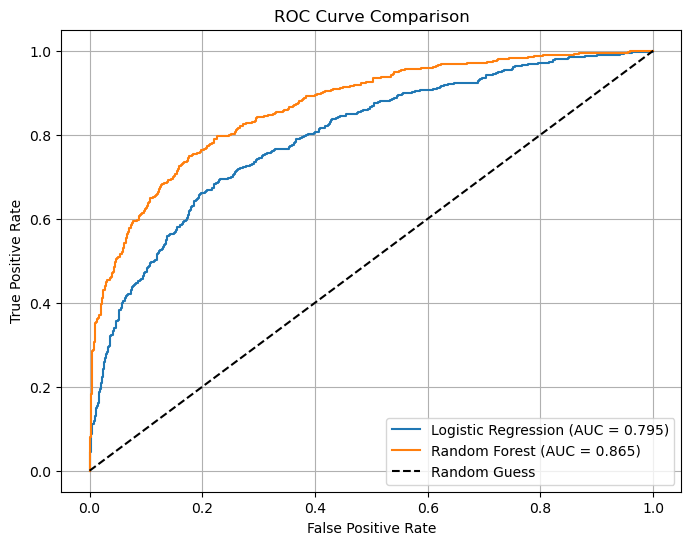

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

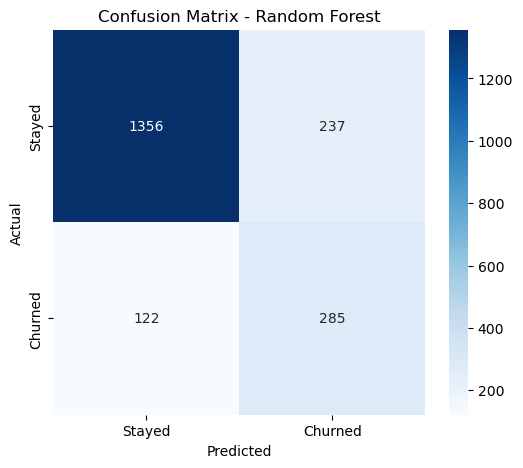

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [37]:
print("Classification Report - Random Forest\n")


print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Stayed','Churned']
))

Classification Report - Random Forest

              precision    recall  f1-score   support

      Stayed       0.92      0.85      0.88      1593
     Churned       0.55      0.70      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



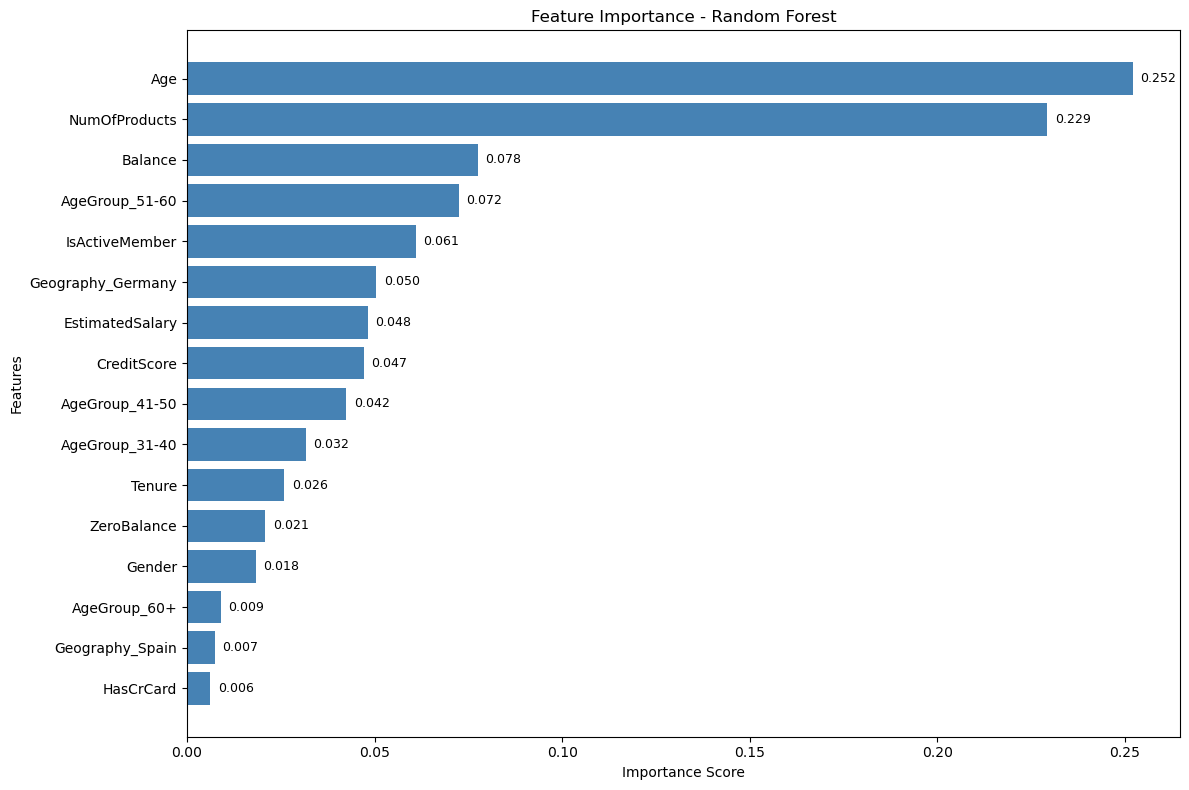

In [38]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12,8))

importances = importances.sort_values()

bars = ax.barh(importances.index,
               importances.values,
               color='steelblue')

ax.set_title("Feature Importance - Random Forest")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Features")

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{width:.3f}",
            va='center',
            fontsize=9)

plt.tight_layout()
plt.show()

In [44]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_explanation = explainer(X_test)

# The model has 2 output classes (stay / churn); keep only the "churn" class
# so every plot below reads as "contribution toward predicting churn".
shap_churn = shap_explanation[:, :, 1]

shap_importances = pd.Series(
    np.abs(shap_churn.values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("Top features by mean |SHAP value| (global importance):")
print(shap_importances.head(8).round(4))

Top features by mean |SHAP value| (global importance):
Age                  0.1049
NumOfProducts        0.0931
IsActiveMember       0.0528
Geography_Germany    0.0361
AgeGroup_51-60       0.0292
Balance              0.0262
Gender               0.0217
AgeGroup_41-50       0.0213
dtype: float64


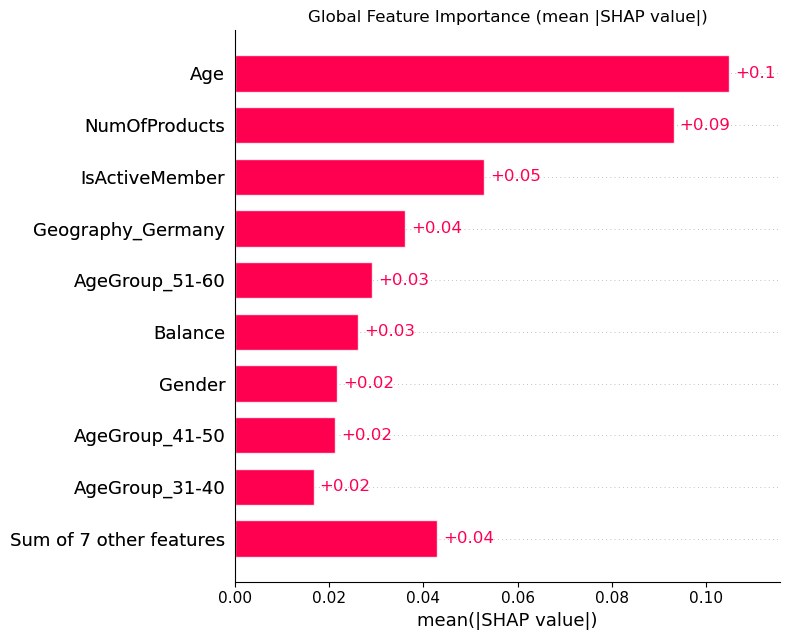

In [45]:
shap.plots.bar(shap_churn, max_display=10, show=False)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

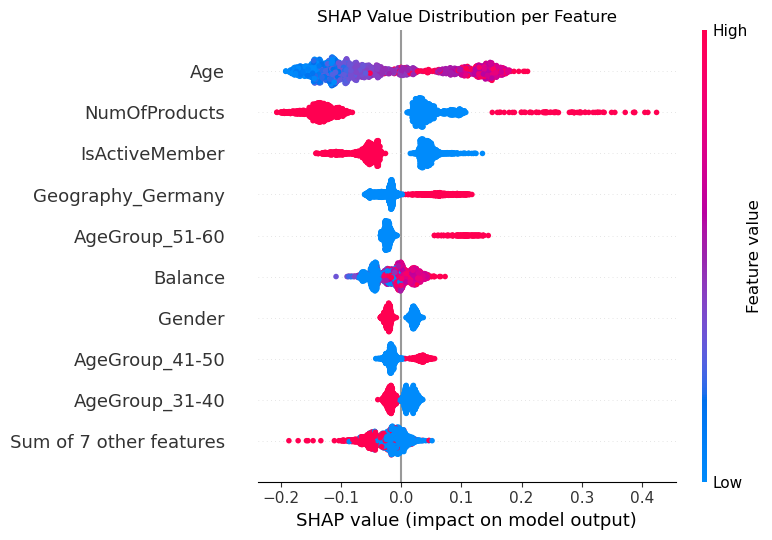

In [46]:
shap.plots.beeswarm(shap_churn, max_display=10, show=False)
plt.title("SHAP Value Distribution per Feature")
plt.tight_layout()
plt.show()

In [47]:
highest_risk_idx = np.argmax(y_proba_rf)
lowest_risk_idx = np.argmin(y_proba_rf)

print("Highest predicted risk -- probability of churn:", round(y_proba_rf[highest_risk_idx], 4))
print(X_test.iloc[highest_risk_idx])
print()
print("Lowest predicted risk -- probability of churn:", round(y_proba_rf[lowest_risk_idx], 4))
print(X_test.iloc[lowest_risk_idx])

Highest predicted risk -- probability of churn: 0.9584
CreditScore                469
Gender                       0
Age                         52
Tenure                       8
Balance              139493.25
NumOfProducts                3
HasCrCard                    0
IsActiveMember               0
EstimatedSalary      150093.32
ZeroBalance                  0
Geography_Germany         True
Geography_Spain          False
AgeGroup_31-40           False
AgeGroup_41-50           False
AgeGroup_51-60            True
AgeGroup_60+             False
Name: 6831, dtype: object

Lowest predicted risk -- probability of churn: 0.0606
CreditScore                756
Gender                       1
Age                         27
Tenure                       8
Balance                    0.0
NumOfProducts                2
HasCrCard                    1
IsActiveMember               1
EstimatedSalary      157932.75
ZeroBalance                  1
Geography_Germany        False
Geography_Spain          Fa

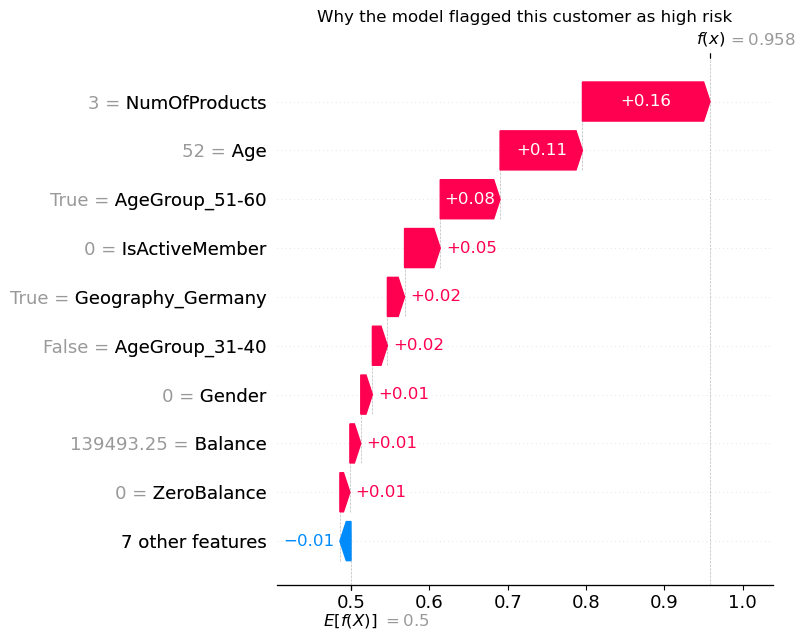

In [48]:
shap.plots.waterfall(shap_churn[highest_risk_idx], show=False)
plt.title("Why the model flagged this customer as high risk")
plt.tight_layout()
plt.show()

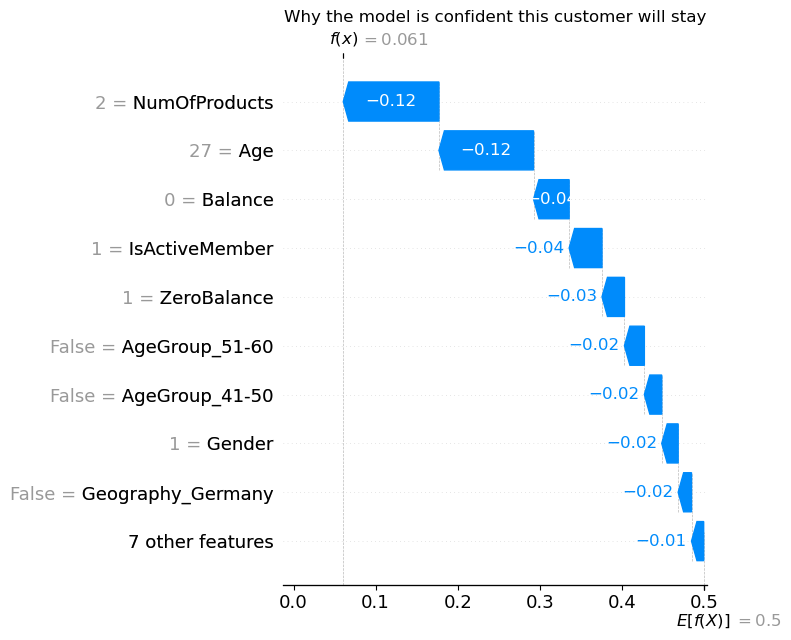

In [49]:
shap.plots.waterfall(shap_churn[lowest_risk_idx], show=False)
plt.title("Why the model is confident this customer will stay")
plt.tight_layout()
plt.show()

In [50]:
# Segment: customers with 3+ products vs. the 2-product baseline
segment_3plus = df_model[df_model['NumOfProducts'] >= 3]
baseline_segment = df_model[df_model['NumOfProducts'] == 2]

n_3plus = len(segment_3plus)
churned_3plus = segment_3plus['Exited'].sum()
rate_3plus = churned_3plus / n_3plus
baseline_rate = baseline_segment['Exited'].mean()

print(f"3+ product customers: {n_3plus} total, {churned_3plus} churned ({rate_3plus:.1%})")
print(f"2-product baseline churn rate: {baseline_rate:.1%} (n={len(baseline_segment)})")

3+ product customers: 326 total, 280 churned (85.9%)
2-product baseline churn rate: 7.6% (n=4590)


In [51]:
# How many of the 3+ product churners are "excess" beyond what we'd expect
# if this segment churned at the same rate as the healthy 2-product segment?
expected_churn_at_baseline = n_3plus * baseline_rate
excess_churned = churned_3plus - expected_churn_at_baseline

avg_balance_3plus_churned = segment_3plus.loc[segment_3plus['Exited'] == 1, 'Balance'].mean()
balance_at_risk = excess_churned * avg_balance_3plus_churned

print(f"Expected churned at baseline rate: {expected_churn_at_baseline:.1f} customers")
print(f"Excess churned customers (3+ products, above baseline expectation): {excess_churned:.1f}")
print(f"Average balance among churned 3+ product customers: ${avg_balance_3plus_churned:,.2f}")
print(f"Estimated excess account balance lost to this pattern: ${balance_at_risk:,.2f}")

Expected churned at baseline rate: 24.7 customers
Excess churned customers (3+ products, above baseline expectation): 255.3
Average balance among churned 3+ product customers: $87,541.67
Estimated excess account balance lost to this pattern: $22,347,957.62


In [52]:
priority_list = pd.DataFrame({
    'Balance': df_model.loc[X_test.index, 'Balance'].values,
    'churn_probability': y_proba_rf,
})
priority_list['expected_value_at_risk'] = (
    priority_list['churn_probability'] * priority_list['Balance']
)

top10 = priority_list.sort_values('expected_value_at_risk', ascending=False).head(10)
print("Top 10 customers by expected value at risk (probability x balance):")
print(top10.round(2))

print(f"\nTotal expected value at risk across the test set: "
      f"${priority_list['expected_value_at_risk'].sum():,.2f}")

Top 10 customers by expected value at risk (probability x balance):
        Balance  churn_probability  expected_value_at_risk
654   250898.09               0.74               184592.06
1825  187602.18               0.88               164858.88
324   186825.57               0.84               157099.86
1364  170008.84               0.89               151431.40
1490  161608.81               0.93               150113.79
1900  213146.20               0.70               150040.02
615   163146.46               0.92               149552.78
1297  164769.02               0.88               144639.80
790   152581.06               0.93               141184.38
978   212696.32               0.66               140006.76

Total expected value at risk across the test set: $67,520,974.27
